## 1. Setting up the environment

### 1.1 Importing the required Libraries

In [1]:
import pandas as pd #import pandas for dataframe manipulation
import numpy as np #to handle the output ...array
from IPython.display import display # Allows the use of display() for DataFrames
import matplotlib.pyplot as plt #matplot for plotting
import matplotlib as mpl #matplot for plotting
import datetime as dt #convert date formats
import seaborn as sns #seaborn for visuals
import os  # File system manangement
import gc # library for memory management
import warnings 
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
#from spicy import stats 

In [2]:
#Setting styling 
pd.options.display.max_columns=60
pd.options.display.max_rows=30
pd.options.display.float_format='{:,.2f}'.format

plt.style.use('ggplot')
plt.rcParams['figure.figsize']=(18,8)
# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format='svg'
%matplotlib inline

## 2. Loading data 

In [3]:
#loading demographics data
traindemographics = pd.read_csv('traindemographics.csv',parse_dates=['birthdate'])
testdemographics = pd.read_csv('testdemographics.csv',parse_dates=['birthdate']) #25% of the data 
#loading prevloans
trainprev=pd.read_csv('trainprevloans.csv',parse_dates=['approveddate','creationdate','closeddate', 'firstduedate', 'firstrepaiddate'])
testprev=pd.read_csv('testprevloans.csv',parse_dates=['approveddate','creationdate','closeddate', 'firstduedate', 'firstrepaiddate'])
#loading perf data
trainperf=pd.read_csv('trainperf.csv',parse_dates=['approveddate','creationdate'])
testperf=pd.read_csv('testperf.csv',parse_dates=['approveddate','creationdate'])

In [4]:
testperf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby
0,8a858899538ddb8e015390510b321f08,301998974,4,40:48.0,39:35.0,10000,"12,250.00",30,NaN
1,8a858959537a097401537a4e316e25f7,301963615,10,43:40.0,42:34.0,40000,"44,000.00",30,NaN
2,8a8589c253ace09b0153af6ba58f1f31,301982236,6,15:11.0,15:04.0,20000,"24,500.00",30,NaN
3,8a858e095aae82b7015aae86ca1e030b,301971730,8,00:54.0,00:49.0,30000,"34,500.00",30,NaN
4,8a858e225a28c713015a30db5c48383d,301959177,4,04:33.0,04:27.0,20000,"24,500.00",30,NaN


In [5]:
trainperf[trainperf['systemloanid']=='301998974']

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag


In [6]:
trainperf[trainperf['customerid']=='8a85886e54beabf90154c0a29ae757c0'] #no revord of this client in previous, but loan number is 2

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41,2017-07-05 16:04:18,"15,000.00","17,250.00",30,NaN,Good


In [7]:
trainperf['good_bad_flag'].value_counts()

good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64

### Explore data

### 2.2 data shape 

In [8]:
#shape of the dataframes

print('Train Demographics: {} Rows, {} Columns'.format(*traindemographics.shape))
print('Test Demographics: {} Rows, {} Columns'.format(*testdemographics.shape))
print ('Trainprev: {} Rows,{} Columns'.format(*trainprev.shape))
print('Testprev: {} Rows,{} Columns'.format(*testprev.shape))
print ('Trainperf: {} Rows,{} Columns'.format(*trainperf.shape))
print('Testperf: {} Rows,{} Columns'.format(*testperf.shape))

Train Demographics: 4346 Rows, 9 Columns
Test Demographics: 1487 Rows, 9 Columns
Trainprev: 18183 Rows,12 Columns
Testprev: 5907 Rows,12 Columns
Trainperf: 4368 Rows,10 Columns
Testperf: 1450 Rows,9 Columns


### 2.3 First Few rows of Data


In [9]:
# Print First Few Rows Of The Data
display('Train Demographics')
display(traindemographics.head(2))
display('Test Demographics')
display(testdemographics.head(2))
display('Train prev')
display(trainprev.head(2))
display('Test prev')
display(testprev.head(2))
display('Train perf')
display(trainperf.head(2))
display('Test perf')
display(testperf.head(2))

'Train Demographics'

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858e135cb22031015cbafc76964ebd,1973-10-10,Savings,3.32,6.53,GT Bank,NaN,NaN,NaN
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21,Savings,3.33,7.12,Sterling Bank,NaN,Permanent,NaN


'Test Demographics'

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
0,8a858f305c8dd672015c93b1db645db4,1976-08-28,Savings,5.30,7.59,Heritage Bank,NaN,Permanent,NaN
1,8a858f085a477386015a47fb049e49ca,1978-06-23,Savings,3.29,6.60,UBA,NaN,Permanent,NaN


'Train prev'

...

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
0,8a858899538ddb8e015390510b321f08,301621635,3,2016-05-17 10:37:00,2016-05-17 09:36:55,"10,000.00","13,000.00",30,2016-06-17 00:04:15,NaN,2016-06-16,2016-06-16 15:44:08
1,8a858959537a097401537a4e316e25f7,301810201,5,2017-02-04 21:28:59,2017-02-04 20:28:52,"30,000.00","36,800.00",60,2017-03-02 16:22:58,NaN,2017-03-06,2017-03-02 16:07:47


'Train perf'

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56,2017-07-25 07:22:47,"30,000.00","34,500.00",30,NaN,Good
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41,2017-07-05 16:04:18,"15,000.00","17,250.00",30,NaN,Good


'Test perf'

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby
0,8a858899538ddb8e015390510b321f08,301998974,4,40:48.0,39:35.0,10000,"12,250.00",30,NaN
1,8a858959537a097401537a4e316e25f7,301963615,10,43:40.0,42:34.0,40000,"44,000.00",30,NaN


### 2.4 Column/Variable Names

Variable names of the data. 

In [10]:
display("train demographics")
display(traindemographics.columns)
display("test demographics")
display(testdemographics.columns)

display("train performance")
display(trainperf.columns)
display("test performance")
display(testperf.columns)

display("train previous loans")
display(trainprev.columns)
display("test previous loans")
display(testprev.columns)

'train demographics'

Index(['customerid', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'bank_branch_clients',
       'employment_status_clients', 'level_of_education_clients'],
      dtype='object')

'test demographics'

Index(['customerid', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'bank_branch_clients',
       'employment_status_clients', 'level_of_education_clients'],
      dtype='object')

'train performance'

...

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby'],
      dtype='object')

'train previous loans'

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate',
       'referredby', 'firstduedate', 'firstrepaiddate'],
      dtype='object')

'test previous loans'

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate',
       'referredby', 'firstduedate', 'firstrepaiddate'],
      dtype='object')

In [11]:
# Number of each type of column
display("train demographics")
display(traindemographics.dtypes.value_counts())
display("test demographics")
display(testdemographics.dtypes.value_counts())

display("train performance")
display(trainperf.dtypes.value_counts())
display("test performance")
display(testperf.dtypes.value_counts())

display("train previous loans")
display(trainprev.dtypes.value_counts())
display("test previous loans")
display(testprev.dtypes.value_counts())

'train demographics'

object            6
float64           2
datetime64[ns]    1
Name: count, dtype: int64

'test demographics'

object            6
float64           2
datetime64[ns]    1
Name: count, dtype: int64

'train performance'

...

object     4
int64      4
float64    1
Name: count, dtype: int64

'train previous loans'

datetime64[ns]    5
int64             3
object            2
float64           2
Name: count, dtype: int64

'test previous loans'

datetime64[ns]    5
int64             3
object            2
float64           2
Name: count, dtype: int64

## 3.5 Data Profiling 

### Use Pandas profiling to get a summary profile of each dataframe 

In [12]:
#from ydata_profiling import ProfileReport

In [13]:
profile = ProfileReport(traindemographics)
profile 
profile.to_file(output_file="traindemographics.html")

profile=ProfileReport(testdemographics)
profile.to_file(output_file = "testdemographics.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
profile=ProfileReport(testperf)
profile.to_file(output_file="testperf.html")

profile=ProfileReport(trainperf)
profile.to_file(output_file="trainperf.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
profile=ProfileReport(trainprev)
profile.to_file(output_file="trainprev.html")

profile=ProfileReport(testprev)
profile.to_file(output_file="testprev.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
print(trainprev.info())
print('-----------------------------------------------')
print(testprev.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customerid       18183 non-null  object        
 1   systemloanid     18183 non-null  int64         
 2   loannumber       18183 non-null  int64         
 3   approveddate     18183 non-null  datetime64[ns]
 4   creationdate     18183 non-null  datetime64[ns]
 5   loanamount       18183 non-null  float64       
 6   totaldue         18183 non-null  float64       
 7   termdays         18183 non-null  int64         
 8   closeddate       18183 non-null  datetime64[ns]
 9   referredby       1026 non-null   object        
 10  firstduedate     18183 non-null  datetime64[ns]
 11  firstrepaiddate  18183 non-null  datetime64[ns]
dtypes: datetime64[ns](5), float64(2), int64(3), object(2)
memory usage: 1.7+ MB
None
-----------------------------------------------
<class 'pandas.

#### More data exploration for traindemographics

In [17]:
traindemographics.isnull().sum()

customerid                       0
birthdate                        0
bank_account_type                0
longitude_gps                    0
latitude_gps                     0
bank_name_clients                0
bank_branch_clients           4295
employment_status_clients      648
level_of_education_clients    3759
dtype: int64

# Dealing with nulls in demographics dataset

In [18]:
traindemographics['employment_status_clients']=traindemographics['employment_status_clients'].fillna('unknown')
traindemographics['level_of_education_clients']=traindemographics['level_of_education_clients'].fillna('unknown')

In [19]:
testdemographics['employment_status_clients']=testdemographics['employment_status_clients'].fillna('unknown')
testdemographics['level_of_education_clients']=testdemographics['level_of_education_clients'].fillna('unknown')
testdemographics['level_of_education_clients'].value_counts() 

level_of_education_clients
unknown          1277
Graduate          157
Secondary          30
Post-Graduate      22
Primary             1
Name: count, dtype: int64

In [20]:
print('testdemographics')
print(testdemographics.isnull().sum())
print('----------------------------------')
print('traindemographics')
print(traindemographics.isnull().sum())

testdemographics
customerid                       0
birthdate                        0
bank_account_type                0
longitude_gps                    0
latitude_gps                     0
bank_name_clients                0
bank_branch_clients           1473
employment_status_clients        0
level_of_education_clients       0
dtype: int64
----------------------------------
traindemographics
customerid                       0
birthdate                        0
bank_account_type                0
longitude_gps                    0
latitude_gps                     0
bank_name_clients                0
bank_branch_clients           4295
employment_status_clients        0
level_of_education_clients       0
dtype: int64


### Testing for and dealing with duplicates in traindemographics

In [21]:
#Testing for duplicates

# traindemographics['customerid'].value_counts() # confirms there are duplicate customerids
traindemographics[traindemographics['customerid']=='8a858fca5c35df2c015c39ad8695343e'] # example of customer records appear 
#traindemographics[traindemographics['customerid']=='8a858f9f5679951a01567a5b90644817'] #some customer records appear duplicated
# confirms there are duplicate data points 

#test dataset
testdemographics[testdemographics['customerid']=='8a858f2e5c699f3a015c6e10b65607c9']


,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
1252,8a858f2e5c699f3a015c6e10b65607c9,1978-06-20,Savings,3.33,6.50,GT Bank,NaN,Permanent,unknown
1285,8a858f2e5c699f3a015c6e10b65607c9,1978-06-20,Savings,3.33,6.50,GT Bank,NaN,Permanent,unknown


In [22]:
testdemographics[testdemographics.duplicated(subset=['customerid', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'employment_status_clients'], keep=False)] #returns the duplicates

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
248,8a858e885b68546c015b7238f22027ba,1975-06-18,Savings,3.35,6.59,First Bank,NaN,Permanent,unknown
497,8a8588b75438f49901544510041e0951,1980-01-16,Other,3.34,6.54,Zenith Bank,NaN,Permanent,Graduate
502,8a8588b75438f49901544510041e0951,1980-01-16,Other,3.34,6.54,Zenith Bank,NaN,Permanent,Graduate
810,8a858e885b68546c015b7238f22027ba,1975-06-18,Savings,3.35,6.59,First Bank,NaN,Permanent,unknown
1252,8a858f2e5c699f3a015c6e10b65607c9,1978-06-20,Savings,3.33,6.50,GT Bank,NaN,Permanent,unknown
1285,8a858f2e5c699f3a015c6e10b65607c9,1978-06-20,Savings,3.33,6.50,GT Bank,NaN,Permanent,unknown


In [23]:
traindemographics[traindemographics.duplicated(subset=['customerid', 'birthdate', 'bank_account_type', 'longitude_gps',
       'latitude_gps', 'bank_name_clients', 'employment_status_clients'], keep=False)] #returns the duplicates

,customerid,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients
138,8a858fca5c35df2c015c39ad8695343e,1980-11-26,Savings,3.35,7.21,GT Bank,NaN,Permanent,unknown
159,8a858fca5c35df2c015c39ad8695343e,1980-11-26,Savings,3.35,7.21,GT Bank,NaN,Permanent,unknown
272,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18,Other,3.78,7.17,First Bank,NaN,Permanent,Secondary
445,8a858e6c5c88d145015c8b9627cd5a48,1979-09-30,Savings,3.37,6.50,Sterling Bank,NaN,Permanent,unknown
517,8a858edd57f790040157ffe9b6ed3fbb,1988-01-18,Other,3.78,7.17,First Bank,NaN,Permanent,Secondary
750,8a858f965bb63a25015bbf63fd062e2e,1974-02-25,Savings,3.94,6.82,Stanbic IBTC,NaN,Permanent,unknown
776,8a858f965bb63a25015bbf63fd062e2e,1974-02-25,Savings,3.94,6.82,Stanbic IBTC,NaN,Permanent,unknown
798,8a858fc75cd62882015cdaf2f4311b3f,1975-10-27,Savings,7.44,9.09,GT Bank,NaN,Permanent,unknown
1010,8a858fe65675195a015679452588279c,1982-08-01,Savings,7.53,9.05,UBA,NaN,Permanent,unknown
1015,8a858fe65675195a015679452588279c,1982-08-01,Savings,7.53,9.05,UBA,NaN,Permanent,unknown


In [24]:
traindemographics=traindemographics.drop_duplicates() #dropped 12 duplicates , 4346-4334=12
testdemographics=testdemographics.drop_duplicates() # dropped 3 duplicates set, 1487-1484=3
#drop 'bank_branch_clients'
cols2drop=['bank_branch_clients','latitude_gps','longitude_gps']
traindemographics=traindemographics.drop(cols2drop, axis=1)
testdemographics=testdemographics.drop(cols2drop, axis=1)

#testdemographics.head(3)
#traindemographics.head(2)

### More data exploration for trainprev

In [25]:
#converting data types for many columns
date_columns = ['closeddate', 'firstduedate', 'firstrepaiddate']
trainprev[date_columns]=trainprev[date_columns].apply(pd.to_datetime,format='%Y-%m-%d')
trainprev['systemloanid']=trainprev['systemloanid'].astype('str')

In [26]:
trainprev.isnull().sum()
#referredby has 17157 nulls, only 1026 records

customerid             0
systemloanid           0
loannumber             0
approveddate           0
creationdate           0
loanamount             0
totaldue               0
termdays               0
closeddate             0
referredby         17157
firstduedate           0
firstrepaiddate        0
dtype: int64

In [27]:
trainprev.describe().T

,count,mean,min,25%,50%,75%,max,std
loannumber,"18,183.00",4.19,1.00,2.00,3.00,6.00,26.00,3.25
approveddate,18183,2017-02-25 09:59:36.147390464,2016-01-15 08:53:28,2016-12-19 16:13:04.500000,2017-04-04 16:44:44,2017-05-27 15:07:16,2017-07-28 10:47:43,NaN
creationdate,18183,2017-02-25 08:55:29.725677824,2016-01-15 07:53:17,2016-12-19 15:12:53.500000,2017-04-04 15:44:31,2017-05-27 14:07:06.500000,2017-07-28 09:46:34,NaN
loanamount,"18,183.00","16,501.24","3,000.00","10,000.00","10,000.00","20,000.00","60,000.00","9,320.55"
totaldue,"18,183.00","19,573.20","3,450.00","11,500.00","13,000.00","24,500.00","68,100.00","10,454.25"
termdays,"18,183.00",26.69,15.00,15.00,30.00,30.00,90.00,10.95
closeddate,18183,2017-03-21 06:55:48.228895232,2016-02-02 08:18:15,2017-01-16 20:53:36,2017-04-27 17:18:59,2017-06-21 19:12:49,2017-07-30 22:09:11,NaN
firstduedate,18183,2017-03-22 09:52:03.642963456,2016-02-15 00:00:00,2017-01-16 00:00:00,2017-05-02 00:00:00,2017-06-22 00:00:00,2017-08-22 00:00:00,NaN
firstrepaiddate,18183,2017-03-20 11:45:09.015893760,2016-02-02 08:13:55,2017-01-14 08:47:29.500000,2017-04-26 21:16:22,2017-06-20 18:22:47,2017-07-30 21:59:01,NaN


In [28]:
filtered_rows = trainprev[trainprev['customerid'] == '8a858fe5569398920156a3a9a77b5d02']
sorted_rows = filtered_rows.sort_values(by='loannumber', ascending=True)

# Display the sorted DataFrame
sorted_rows

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
16227,8a858fe5569398920156a3a9a77b5d02,301691222,1,2016-08-23 07:07:04,2016-08-23 06:06:56,"10,000.00","13,000.00",30,2016-09-19 20:47:57,NaN,2016-09-22,2016-09-19 20:32:52
13981,8a858fe5569398920156a3a9a77b5d02,301728684,2,2016-09-26 11:44:20,2016-09-26 10:44:11,"10,000.00","13,000.00",30,2016-10-08 15:06:07,NaN,2016-10-26,2016-10-08 14:50:58
13983,8a858fe5569398920156a3a9a77b5d02,301739827,3,2016-10-08 15:56:23,2016-10-08 14:56:14,"20,000.00","24,500.00",30,2016-10-21 08:25:10,NaN,2016-11-07,2016-10-21 08:10:00
9938,8a858fe5569398920156a3a9a77b5d02,301747643,4,2016-10-21 08:55:50,2016-10-21 07:55:40,"20,000.00","24,500.00",30,2016-11-15 11:55:15,NaN,2016-11-21,2016-11-15 11:40:05
9936,8a858fe5569398920156a3a9a77b5d02,301759511,5,2016-11-15 12:58:25,2016-11-15 10:59:51,"20,000.00","23,800.00",30,2016-11-16 07:38:09,NaN,2016-12-15,2016-11-16 07:22:59
10316,8a858fe5569398920156a3a9a77b5d02,301759935,6,2016-11-16 08:41:23,2016-11-16 07:41:13,"30,000.00","36,800.00",60,2016-11-18 12:37:16,NaN,2016-12-16,2016-11-18 12:22:07
16230,8a858fe5569398920156a3a9a77b5d02,301761283,7,2016-11-18 14:48:10,2016-11-18 13:48:00,"30,000.00","34,400.00",30,2016-12-03 13:00:14,NaN,2016-12-19,2016-12-03 12:45:05
13984,8a858fe5569398920156a3a9a77b5d02,301768895,8,2016-12-03 15:04:59,2016-12-03 14:03:44,"30,000.00","34,400.00",30,2016-12-15 21:42:00,NaN,2017-01-02,2016-12-15 21:26:50
16229,8a858fe5569398920156a3a9a77b5d02,301774855,9,2016-12-15 21:45:42,2016-12-15 20:45:31,"40,000.00","44,800.00",30,2016-12-26 12:19:14,NaN,2017-01-16,2016-12-26 12:04:04
10320,8a858fe5569398920156a3a9a77b5d02,301781645,10,2016-12-26 12:36:23,2016-12-26 11:36:12,"40,000.00","44,800.00",30,2016-12-28 19:58:28,NaN,2017-01-25,2016-12-28 19:43:19


In [29]:
trainprev['referredby'].value_counts() # column to drop 

referredby
8a858fc55b2548dd015b286e452c678c    14
8a858f965bb63a25015bc2ddf2577416     9
8a858ebb5adce699015adea5d5ae51b3     9
8a8589f35451855401547fc55caa6cd5     8
8a858e025ab3a6c2015ab74cfa5c4431     7
                                    ..
8a858fb959976ce0015998f0a628583b     1
8a858ee65be8d42d015be94e806334fe     1
8a858f5e5cb23c77015cc061b752625b     1
8a858fea5b391cd7015b393aed9e2a04     1
8a858eaa55a0b8ae0155ad2cab5e49cc     1
Name: count, Length: 521, dtype: int64

In [30]:
trainprev['termdays'].value_counts()

termdays
30    11045
15     6115
60      993
90       30
Name: count, dtype: int64

In [31]:
trainprev[trainprev.duplicated(subset=['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'closeddate',
       'referredby', 'firstduedate', 'firstrepaiddate'], keep=False)]
#no duplicated identified 

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate


In [32]:
trainprev[trainprev['loannumber']==22]

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate
950,8a858f7d5578012a01557ea194d94948,301840987,22,2017-03-18 10:29:08,2017-03-18 09:28:59,"50,000.00","57,500.00",90,2017-06-05 09:56:43,NaN,2017-04-17,2017-04-07 15:27:45
16774,8a858e4456ced8470156d73452f85335,301936806,22,2017-06-13 07:05:01,2017-06-13 06:04:53,"60,000.00","62,700.00",30,2017-07-06 12:15:12,NaN,2017-07-13,2017-07-06 12:05:03


## 3. Features engineering

### Data merging (train and test)

In [33]:
traindemographics['dataset']='train'
testdemographics['dataset']='test'
#appended_demographics=traindemographics.append(testdemographics, ignore_index=True)
#appended_demographics = pd.concat([traindemographics, testdemographics], ignore_index=True)
appended_demographics = pd.concat([traindemographics, testdemographics], ignore_index=True)
appended_demographics.shape

(5818, 7)

In [34]:
appended_demographics.tail(3)

,customerid,birthdate,bank_account_type,bank_name_clients,employment_status_clients,level_of_education_clients,dataset
5815,8a858e8b5bc9e7e6015bcd7374077f0c,1988-06-12,Savings,First Bank,Permanent,unknown,test
5816,8a858f2e5c699f3a015c77aa22ed7f23,1974-03-23,Savings,FCMB,Permanent,unknown,test
5817,8a858fde580afd48015818eda53830c8,1987-02-16,Savings,Stanbic IBTC,Permanent,Graduate,test


In [35]:
#To establish the age of Customers and categorise them by age into bins 
# Split the date_column into year, month, and day columns
appended_demographics['birthdate'] = appended_demographics['birthdate'].astype(str)
appended_demographics[['Year','Month','Day']] = appended_demographics['birthdate'].str.split('-',expand=True)
appended_demographics['customer_age']= 2020-appended_demographics['Year'].astype('int') #used 2020 given that the challenge is old
appended_demographics[['Year','birthdate','customer_age']]

#create age_category
bins=[0,30,35,45,60]
labels =['youth','young_adult','adult','retired']
appended_demographics['age_categ']=pd.cut(appended_demographics['customer_age'],bins=bins,labels=labels)
appended_demographics['age_categ'].value_counts()

age_categ
adult          2382
young_adult    1883
youth          1116
retired         437
Name: count, dtype: int64

In [36]:
appended_demographics.head(2)

,customerid,birthdate,bank_account_type,bank_name_clients,employment_status_clients,level_of_education_clients,dataset,Year,Month,Day,customer_age,age_categ
0,8a858e135cb22031015cbafc76964ebd,1973-10-10,Savings,GT Bank,unknown,unknown,train,1973,10,10,47,retired
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21,Savings,Sterling Bank,Permanent,unknown,train,1986,01,21,34,young_adult


In [37]:
appended_demographics['customer_age'].mode()

0    34
Name: customer_age, dtype: int64

In [38]:
appended_demographics['level_of_education_clients'].isnull().sum()
appended_demographics['level_of_education_clients']=appended_demographics['level_of_education_clients'].fillna('unknown')
#appended_demographics['level_of_education_clients'].value_counts()
appended_demographics['education_flag'] = appended_demographics['level_of_education_clients'].apply(lambda x: 0 if x == 'unknown' else 1)
appended_demographics['employment_flag'] = appended_demographics['employment_status_clients'].apply(lambda x: 0 if x == 'unknown' else 1)
appended_demographics['bnk_acc_typ_flag'] = appended_demographics['bank_account_type'].apply(lambda x: 1 if x == 'Savings' else 0)
appended_demographics.head(2)

,customerid,birthdate,bank_account_type,bank_name_clients,employment_status_clients,level_of_education_clients,dataset,Year,Month,Day,customer_age,age_categ,education_flag,employment_flag,bnk_acc_typ_flag
0,8a858e135cb22031015cbafc76964ebd,1973-10-10,Savings,GT Bank,unknown,unknown,train,1973,10,10,47,retired,0,0,1
1,8a858e275c7ea5ec015c82482d7c3996,1986-01-21,Savings,Sterling Bank,Permanent,unknown,train,1986,01,21,34,young_adult,0,1,1


In [39]:
appended_demographics=appended_demographics[['customerid','dataset','age_categ', 'education_flag','employment_flag', 'bnk_acc_typ_flag']]
appended_demographics

,customerid,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag
0,8a858e135cb22031015cbafc76964ebd,train,retired,0,0,1
1,8a858e275c7ea5ec015c82482d7c3996,train,young_adult,0,1,1
2,8a858e5b5bd99460015bdc95cd485634,train,young_adult,0,0,1
3,8a858efd5ca70688015cabd1f1e94b55,train,youth,0,1,1
4,8a858e785acd3412015acd48f4920d04,train,adult,0,1,1
...,...,...,...,...,...,...
5813,8a858fc25bafabdc015bb47fda0323e5,test,adult,0,1,1
5814,8a858e245c214660015c3397e4db389a,test,youth,0,1,1
5815,8a858e8b5bc9e7e6015bcd7374077f0c,test,young_adult,0,1,1
5816,8a858f2e5c699f3a015c77aa22ed7f23,test,retired,0,1,1


In [40]:
appended_demographics.head()

,customerid,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag
0,8a858e135cb22031015cbafc76964ebd,train,retired,0,0,1
1,8a858e275c7ea5ec015c82482d7c3996,train,young_adult,0,1,1
2,8a858e5b5bd99460015bdc95cd485634,train,young_adult,0,0,1
3,8a858efd5ca70688015cabd1f1e94b55,train,youth,0,1,1
4,8a858e785acd3412015acd48f4920d04,train,adult,0,1,1


### Loan history features

In [41]:
trainprev['dataset']='train'
testprev['dataset']='test'
appended_loanhistory = pd.concat([trainprev, testprev], ignore_index=True)
appended_loanhistory.tail(3)

trainperf['dataset']='train'
testperf['dataset']='test'

appended_perf = pd.concat([trainperf, testperf], ignore_index=True)
#appended_perf.tail(3)

In [42]:
appended_perf['referredby']=appended_perf['referredby'].fillna('not_referred')
appended_loanhistory['referredby']=appended_loanhistory['referredby'].fillna('not_referred')
#appended_perf['good_bad_flag'].isnull().sum()  #the nulls are from the test set

In [43]:
#for previous loans
appended_loanhistory['loan_interest']= appended_loanhistory['totaldue']- appended_loanhistory['loanamount']
appended_loanhistory['%loan_int']=(appended_loanhistory['loan_interest']/appended_loanhistory['loanamount'])*100

# current loan_perf
appended_perf['loan_interest']= appended_perf['totaldue']-appended_perf['loanamount']
appended_perf['%loan_int']=(appended_perf['loan_interest']/appended_perf['loanamount'])*100

In [44]:
appended_loanhistory['%loan_int'].value_counts() #make bins from the rates

%loan_int
30.00    7841
15.00    6997
22.50    1852
19.00    1614
14.67    1155
         ... 
20.33       2
0.00        1
10.75       1
28.33       1
21.00       1
Name: count, Length: 51, dtype: int64

In [45]:
# create loan interest category bands
bins=[0,10,20,30]
labels =['low','medium','high']
appended_loanhistory['loan_rateCat']=pd.cut(appended_loanhistory['%loan_int'],bins=bins,labels=labels)

# create loan interest category bands
appended_perf['loan_rateCat']=pd.cut(appended_perf['%loan_int'],bins=bins,labels=labels)
appended_perf['loan_rateCat'].value_counts()

loan_rateCat
high      3299
medium    2017
low        501
Name: count, dtype: int64

In [46]:
appended_loanhistory.isnull().sum()

customerid         0
systemloanid       0
loannumber         0
approveddate       0
creationdate       0
loanamount         0
totaldue           0
termdays           0
closeddate         0
referredby         0
firstduedate       0
firstrepaiddate    0
dataset            0
loan_interest      0
%loan_int          0
loan_rateCat       1
dtype: int64

In [47]:
# Add days from 'termdays' column to 'approveddate' to get the loan due date and determine and add a column with late payment and early payments flag
appended_loanhistory['loan_due_dateCALC'] = appended_loanhistory['approveddate'] + pd.to_timedelta(appended_loanhistory['termdays'], unit='D')

In [48]:
appended_loanhistory.head(3)

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate,dataset,loan_interest,%loan_int,loan_rateCat,loan_due_dateCALC
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40,2016-08-15 17:22:32,"10,000.00","13,000.00",30,2016-09-01 16:06:48,not_referred,2016-09-14,2016-09-01 15:51:43,train,"3,000.00",30.00,high,2016-09-14 18:22:40
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07,2017-04-28 17:38:53,"10,000.00","13,000.00",30,2017-05-28 14:44:49,not_referred,2017-05-30,2017-05-26 00:00:00,train,"3,000.00",30.00,high,2017-05-28 18:39:07
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25,2017-03-05 09:56:19,"20,000.00","23,800.00",30,2017-04-26 22:18:56,not_referred,2017-04-04,2017-04-26 22:03:47,train,"3,800.00",19.00,medium,2017-04-04 10:56:25


good_bad_flag
Good    3416
Bad      952
Name: count, dtype: int64


Text(0.5, 0, 'good_bad_flag')

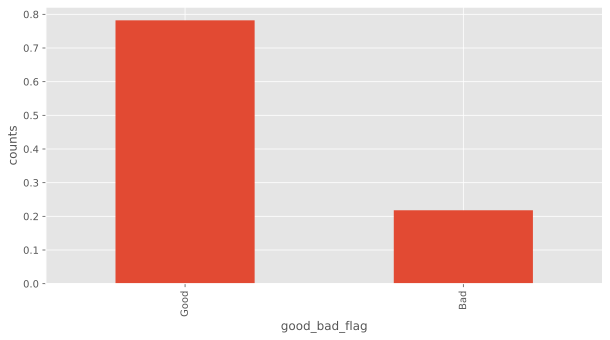

In [49]:
#Check if the predictor class is balanced 
print(trainperf['good_bad_flag'].value_counts())
plt.figure(figsize=(10,5))
trainperf['good_bad_flag'].value_counts(normalize=True).plot(kind='bar')
plt.ylabel('counts')
plt.xlabel('good_bad_flag')

In [50]:
appended_perf.head(3)

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,dataset,loan_interest,%loan_int,loan_rateCat
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56,2017-07-25 07:22:47,"30,000.00","34,500.00",30,not_referred,Good,train,"4,500.00",15.00,medium
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41,2017-07-05 16:04:18,"15,000.00","17,250.00",30,not_referred,Good,train,"2,250.00",15.00,medium
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57,2017-07-06 13:52:51,"20,000.00","22,250.00",15,not_referred,Good,train,"2,250.00",11.25,medium


In [51]:
#create a column containing frequency of loans - count of loans previously taken
customer_counts=appended_loanhistory['customerid'].value_counts().reset_index()
customer_counts.columns = ['customerid', 'loan_freq']# loan_frequency -  count of loans 

# Merge the counts back into the original DataFrame
appended_demographics=pd.merge(appended_demographics,customer_counts,on='customerid', how='left')
#appended_demographics[appended_demographics['customerid']=='8a2a81a74ce8c05d014cfb32a0da1049']
#appended_loanhistory[appended_loanhistory['customerid']=='8a2a81a74ce8c05d014cfb32a0da1049']

In [52]:
#no of days taken to pay loan

In [53]:
# Days taken to pay loan payment time
appended_loanhistory['days_taken2']=appended_loanhistory['closeddate'] - appended_loanhistory['approveddate']
appended_loanhistory['days_taken'] = appended_loanhistory['days_taken2'].dt.days
appended_loanhistory['late_flag'] = appended_loanhistory.apply(lambda row: 'ontime' if row['days_taken'] <= row['termdays'] else 'is_late', axis=1)

In [54]:
appended_loanhistory.head(2)

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate,dataset,loan_interest,%loan_int,loan_rateCat,loan_due_dateCALC,days_taken2,days_taken,late_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40,2016-08-15 17:22:32,"10,000.00","13,000.00",30,2016-09-01 16:06:48,not_referred,2016-09-14,2016-09-01 15:51:43,train,"3,000.00",30.00,high,2016-09-14 18:22:40,16 days 21:44:08,16,ontime
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07,2017-04-28 17:38:53,"10,000.00","13,000.00",30,2017-05-28 14:44:49,not_referred,2017-05-30,2017-05-26 00:00:00,train,"3,000.00",30.00,high,2017-05-28 18:39:07,29 days 20:05:42,29,ontime


In [55]:
# Days taken to pay loan payment time

appended_loanhistory[['days_taken2','days_taken','termdays','late_flag']]

,days_taken2,days_taken,termdays,late_flag
0,16 days 21:44:08,16,30,ontime
1,29 days 20:05:42,29,30,ontime
2,52 days 11:22:31,52,30,is_late
3,14 days 07:09:57,14,15,ontime
4,27 days 11:48:46,27,15,is_late
...,...,...,...,...
24085,22 days 23:22:31,22,30,ontime
24086,9 days 19:59:25,9,15,ontime
24087,16 days 21:26:15,16,30,ontime
24088,29 days 15:04:07,29,30,ontime


In [56]:

#average time taken client takes to pay back loans 

# Group by client and calculate the average time taken 
average_time = appended_loanhistory.groupby('customerid')['days_taken'].mean().reset_index()# average time taken by client 
# Rename the 'days taken' column to 'avg_paybacktime'
average_time=average_time.rename(columns={'days_taken':'avg_paybacktime'})

appended_demographics=pd.merge(appended_demographics,average_time, on='customerid',how='left')

In [57]:
#average loan previously taken by client 

# Group by client and calculate the average loan taken before
average_loan = appended_loanhistory.groupby('customerid')['loanamount'].mean().reset_index()# average loan taken by client 
# Rename the 'loanamount' column to 'clients_avg_loanAMT'
average_loan=average_loan.rename(columns={'loanamount':'clients_avg_loanAMT'})
#average_loan['customerid'].value_counts()# to confirm the counts

#Merge the average_loan with the original DF on 'customerid' column
#appended_loanhistory=pd.merge(appended_loanhistory,average_loan, on='customerid',how='left')
appended_demographics=pd.merge(appended_demographics,average_loan, on='customerid',how='left')

#maximum loan previously taken by client 

# Group by client and calculate the max loan taken before
max_loan = appended_loanhistory.groupby('customerid')['loanamount'].max().reset_index()# max loan taken by client 
# Rename the 'loanamount' column to 'clients_max_loanAMT'
max_loan=max_loan.rename(columns={'loanamount':'clients_max_loanAMT'})
#max_loan['customerid'].value_counts()# to confirm the counts

#Merge the max_loan with the original DF on 'customerid' column
#appended_loanhistory=pd.merge(appended_loanhistory,max_loan, on='customerid',how='left')
appended_demographics=pd.merge(appended_demographics,max_loan, on='customerid',how='left')

#minimum loan previously taken by client 

# Group by client and calculate the max loan taken before
min_loan = appended_loanhistory.groupby('customerid')['loanamount'].min().reset_index()# max loan taken by client 
# Rename the 'loanamount' column to 'clients_min_loanAMT'
min_loan=min_loan.rename(columns={'loanamount':'clients_min_loanAMT'})
#min_loan['customerid'].value_counts()# to confirm the counts

#Merge the min_loan with the original DF on 'customerid' column
#appended_loanhistory=pd.merge(appended_loanhistory,min_loan, on='customerid',how='left')
appended_demographics=pd.merge(appended_demographics,min_loan, on='customerid',how='left')

#most frequent loan amt previously taken by client 

# Group by client and calculate the modal loan taken before
modal_loan = appended_loanhistory.groupby('customerid')['loanamount'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

# Rename the 'loanamount' column to 'clients_modal_loanAMT'
modal_loan = modal_loan.rename(columns={'loanamount': 'clients_modal_loanAMT'})

#Merge the min_loan with the original DF on 'customerid' column
# appended_loanhistory=pd.merge(appended_loanhistory,modal_loan, on='customerid',how='left')
appended_demographics=pd.merge(appended_demographics,modal_loan, on='customerid',how='left')

In [58]:
appended_demographics[appended_demographics['customerid'] == '8a858fe5569398920156a3a9a77b5d02']

,customerid,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT
3488,8a858fe5569398920156a3a9a77b5d02,train,youth,1,1,0,21.00,14.62,"36,666.67","60,000.00","10,000.00","40,000.00"


In [59]:
filtered_rows = appended_loanhistory[appended_loanhistory['customerid'] == '8a1a1e7e4f707f8b014f797718316cad']
sorted_rows2 = filtered_rows.sort_values(by='loannumber', ascending=True)

# Display the sorted DataFrame
sorted_rows2

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate,dataset,loan_interest,%loan_int,loan_rateCat,loan_due_dateCALC,days_taken2,days_taken,late_flag
5216,8a1a1e7e4f707f8b014f797718316cad,301620412,1,2016-05-13 15:29:37,2016-05-13 14:29:31,"10,000.00","13,000.00",30,2016-06-15 00:03:33,not_referred,2016-06-13,2016-06-14 10:41:13,train,"3,000.00",30.00,high,2016-06-12 15:29:37,32 days 08:33:56,32,is_late
17546,8a1a1e7e4f707f8b014f797718316cad,301632940,2,2016-06-15 11:22:38,2016-06-15 10:22:32,"10,000.00","13,000.00",30,2016-07-15 13:59:02,not_referred,2016-07-15,2016-07-15 13:43:58,train,"3,000.00",30.00,high,2016-07-15 11:22:38,30 days 02:36:24,30,ontime
7999,8a1a1e7e4f707f8b014f797718316cad,301916386,3,2017-05-23 14:21:42,2017-05-23 13:20:30,"20,000.00","24,500.00",30,2017-06-21 21:58:00,not_referred,2017-06-22,2017-06-21 21:47:51,train,"4,500.00",22.50,high,2017-06-22 14:21:42,29 days 07:36:18,29,ontime
16602,8a1a1e7e4f707f8b014f797718316cad,301947045,4,2017-06-21 22:09:51,2017-06-21 21:09:44,"30,000.00","39,000.00",60,2017-07-26 19:48:11,not_referred,2017-07-21,2017-07-20 15:05:33,train,"9,000.00",30.00,high,2017-08-20 22:09:51,34 days 21:38:20,34,ontime


In [60]:
# Group by 'customerid' and calculate total loans and 'ontime' loans
ontime_status_grp = appended_loanhistory.groupby('customerid')['late_flag'].agg(total_loans='count',ontime_loans=lambda x: (x == 'ontime').sum()
).reset_index()

# Calculate percentage of 'ontime' loans
ontime_status_grp['ontime_percentage'] = (ontime_status_grp['ontime_loans'] / ontime_status_grp['total_loans']) * 100



In [61]:
# pays_late_risk

#finaldf['good_bad_flag'] = finaldf['good_bad_flag'].apply(lambda x: 0 if x == 'bad' else 1)
ontime_status_grp['pays_late_risk']=ontime_status_grp['ontime_percentage'].apply(lambda x: 1 if x >90 else 0)

In [62]:
ontime_status_grp

,customerid,total_loans,ontime_loans,ontime_percentage,pays_late_risk
0,8a1088a0484472eb01484669e3ce4e0b,1,0,0.00,0
1,8a1a1e7e4f707f8b014f797718316cad,4,3,75.00,0
2,8a1a32fc49b632520149c3b8fdf85139,7,6,85.71,0
3,8a1eb5ba49a682300149c3c068b806c7,8,8,100.00,1
4,8a1edbf14734127f0147356fdb1b1eb2,2,2,100.00,1
...,...,...,...,...,...
5796,8a858fff5c79144c015c7bdbfc086ce1,1,1,100.00,1
5797,8aaae7a74400b28201441c8b62514150,3,3,100.00,1
5798,8aab10f748cf78ff0148d11fac1447a6,1,0,0.00,0
5799,8aab160f499477da014999ba2f0f578b,3,2,66.67,0


In [63]:
appended_loanhistory[appended_loanhistory['customerid']=='8aab10f748cf78ff0148d11fac1447a6']

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate,dataset,loan_interest,%loan_int,loan_rateCat,loan_due_dateCALC,days_taken2,days_taken,late_flag
22961,8aab10f748cf78ff0148d11fac1447a6,301940083,1,2017-06-15 18:03:58,2017-06-15 17:02:49,"10,000.00","13,000.00",30,2017-07-19 20:30:15,not_referred,2017-07-17,2017-07-19 20:20:06,test,"3,000.00",30.00,high,2017-07-15 18:03:58,34 days 02:26:17,34,is_late


In [64]:
#Merge the min_loan with the original DF on 'customerid' column
# appended_loanhistory=pd.merge(appended_loanhistory,ontime_status_grp, on='customerid',how='left')
appended_demographics=pd.merge(appended_demographics,ontime_status_grp, on='customerid',how='left')

In [65]:
appended_demographics.head(3)

,customerid,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk
0,8a858e135cb22031015cbafc76964ebd,train,retired,0,0,1,1.00,15.00,"10,000.00","10,000.00","10,000.00","10,000.00",1.00,1.00,100.00,1.00
1,8a858e275c7ea5ec015c82482d7c3996,train,young_adult,0,1,1,1.00,32.00,"10,000.00","10,000.00","10,000.00","10,000.00",1.00,0.00,0.00,0.00
2,8a858e5b5bd99460015bdc95cd485634,train,young_adult,0,0,1,3.00,20.67,"10,000.00","10,000.00","10,000.00","10,000.00",3.00,1.00,33.33,0.00


In [66]:
trainperf.head(3)

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,dataset
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56,2017-07-25 07:22:47,"30,000.00","34,500.00",30,NaN,Good,train
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41,2017-07-05 16:04:18,"15,000.00","17,250.00",30,NaN,Good,train
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57,2017-07-06 13:52:51,"20,000.00","22,250.00",15,NaN,Good,train


In [67]:
#trainperf['good_bad_flag'].value_counts()

In [68]:
trainperf.columns

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'good_bad_flag', 'dataset'],
      dtype='object')

In [69]:
trainperf['referredby']=trainperf['referredby'].fillna('not_referred')


In [70]:
trainperf['referredby'].value_counts()

referredby
not_referred                        3781
8a858fc55b2548dd015b286e452c678c       8
8a858f965bb63a25015bc2ddf2577416       3
8a858eeb5bb559d3015bb57fa13f10de       3
8a858e125b391784015b395fa56243e6       3
                                    ... 
8a858e3d5c3b5122015c43f776bd4a3a       1
8a858f7a5b39a003015b39ca67ab2efb       1
8a858fa359d61dae0159d698bf503d29       1
8a858e6f5cd5e874015ce084c86e2a87       1
8a858eda5c8863ff015c9dead65807bb       1
Name: count, Length: 522, dtype: int64

In [71]:
appended_loanhistory.head(3)

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,closeddate,referredby,firstduedate,firstrepaiddate,dataset,loan_interest,%loan_int,loan_rateCat,loan_due_dateCALC,days_taken2,days_taken,late_flag
0,8a2a81a74ce8c05d014cfb32a0da1049,301682320,2,2016-08-15 18:22:40,2016-08-15 17:22:32,"10,000.00","13,000.00",30,2016-09-01 16:06:48,not_referred,2016-09-14,2016-09-01 15:51:43,train,"3,000.00",30.00,high,2016-09-14 18:22:40,16 days 21:44:08,16,ontime
1,8a2a81a74ce8c05d014cfb32a0da1049,301883808,9,2017-04-28 18:39:07,2017-04-28 17:38:53,"10,000.00","13,000.00",30,2017-05-28 14:44:49,not_referred,2017-05-30,2017-05-26 00:00:00,train,"3,000.00",30.00,high,2017-05-28 18:39:07,29 days 20:05:42,29,ontime
2,8a2a81a74ce8c05d014cfb32a0da1049,301831714,8,2017-03-05 10:56:25,2017-03-05 09:56:19,"20,000.00","23,800.00",30,2017-04-26 22:18:56,not_referred,2017-04-04,2017-04-26 22:03:47,train,"3,800.00",19.00,medium,2017-04-04 10:56:25,52 days 11:22:31,52,is_late


In [72]:
appended_demographics[appended_demographics['customerid']=='8a858959537a097401537a4e316e25f7']

,customerid,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk
3191,8a858959537a097401537a4e316e25f7,train,young_adult,0,1,1,9.00,24.11,"23,888.89","40,000.00","5,000.00","30,000.00",9.00,8.00,88.89,0.00


In [73]:
#Preparing the testdf
testperf=pd.read_csv('testperf.csv',parse_dates=['approveddate','creationdate'])

# Inner join
testdf_final = pd.merge(testperf, appended_demographics, on='customerid', how='inner')

In [74]:
#appended_df_final = pd.concat([trainperf,appended_demographics])
# Inner join
result_df_final = pd.merge(trainperf, appended_demographics, on='customerid', how='inner')

# appended_df_final

# ### merge the results of the features in the history and extract one customer ID ---------#####-

In [75]:
testdf_final.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk
0,8a858899538ddb8e015390510b321f08,301998974,4,40:48.0,39:35.0,10000,"12,250.00",30,NaN,train,adult,0,1,0,3.00,28.33,"8,666.67","10,000.00","6,000.00","10,000.00",3.00,2.00,66.67,0.00
1,8a858959537a097401537a4e316e25f7,301963615,10,43:40.0,42:34.0,40000,"44,000.00",30,NaN,train,young_adult,0,1,1,9.00,24.11,"23,888.89","40,000.00","5,000.00","30,000.00",9.00,8.00,88.89,0.00
2,8a8589c253ace09b0153af6ba58f1f31,301982236,6,15:11.0,15:04.0,20000,"24,500.00",30,NaN,test,adult,0,1,1,5.00,31.20,"13,000.00","20,000.00","10,000.00","10,000.00",5.00,2.00,40.00,0.00
3,8a858e095aae82b7015aae86ca1e030b,301971730,8,00:54.0,00:49.0,30000,"34,500.00",30,NaN,train,adult,0,0,1,7.00,13.43,"17,142.86","30,000.00","10,000.00","10,000.00",7.00,7.00,100.00,1.00
4,8a858e225a28c713015a30db5c48383d,301959177,4,04:33.0,04:27.0,20000,"24,500.00",30,NaN,test,adult,0,1,1,3.00,21.67,"10,000.00","10,000.00","10,000.00","10,000.00",3.00,3.00,100.00,1.00


In [76]:
result_df_final.columns

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'good_bad_flag', 'dataset_x', 'dataset_y', 'age_categ',
       'education_flag', 'employment_flag', 'bnk_acc_typ_flag', 'loan_freq',
       'avg_paybacktime', 'clients_avg_loanAMT', 'clients_max_loanAMT',
       'clients_min_loanAMT', 'clients_modal_loanAMT', 'total_loans',
       'ontime_loans', 'ontime_percentage', 'pays_late_risk'],
      dtype='object')

In [77]:
testdf_final.columns

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'dataset', 'age_categ', 'education_flag', 'employment_flag',
       'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk'],
      dtype='object')

In [78]:
result_df_final=result_df_final[['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'good_bad_flag', 'dataset_x', 'age_categ',
       'education_flag', 'employment_flag', 'bnk_acc_typ_flag', 'loan_freq',
       'avg_paybacktime', 'clients_avg_loanAMT', 'clients_max_loanAMT',
       'clients_min_loanAMT', 'clients_modal_loanAMT', 'total_loans',
       'ontime_loans', 'ontime_percentage', 'pays_late_risk']]

In [79]:
testdf_final=testdf_final[['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby','dataset', 'age_categ', 'education_flag', 'employment_flag',
       'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime','clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans','ontime_percentage', 'pays_late_risk']]

In [80]:
testdf_final.isnull().sum()

customerid                  0
systemloanid                0
loannumber                  0
approveddate                0
creationdate                0
loanamount                  0
totaldue                    0
termdays                    0
referredby               1266
dataset                     0
age_categ                   0
education_flag              0
employment_flag             0
bnk_acc_typ_flag            0
loan_freq                   8
avg_paybacktime             8
clients_avg_loanAMT         8
clients_max_loanAMT         8
clients_min_loanAMT         8
clients_modal_loanAMT       8
total_loans                 8
ontime_loans                8
ontime_percentage           8
pays_late_risk              8
dtype: int64

In [81]:
result_df_final.isnull().sum()

customerid               0
systemloanid             0
loannumber               0
approveddate             0
creationdate             0
loanamount               0
totaldue                 0
termdays                 0
referredby               0
good_bad_flag            0
dataset_x                0
age_categ                0
education_flag           0
employment_flag          0
bnk_acc_typ_flag         0
loan_freq                9
avg_paybacktime          9
clients_avg_loanAMT      9
clients_max_loanAMT      9
clients_min_loanAMT      9
clients_modal_loanAMT    9
total_loans              9
ontime_loans             9
ontime_percentage        9
pays_late_risk           9
dtype: int64

In [82]:
#result_df_final[['customerid','clients_avg_loanAMT']]

In [83]:
#trainprev[trainprev['customerid']=='8a85886e54beabf90154c0a29ae757c0']

In [84]:
appended_demographics[appended_demographics['customerid']=='8a85886e54beabf90154c0a29ae757c0']
# never got a loan before 


,customerid,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk
3396,8a85886e54beabf90154c0a29ae757c0,train,young_adult,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
result_df_final.shape
#dropped this record since i wont be able to calculate feature engineered columns 

(4368, 25)

In [86]:
testdf_final.shape

(1450, 24)

In [87]:
testdf_final['referredby']=testdf_final['referredby'].fillna('not_referred')

In [88]:

testdf_final=testdf_final.dropna() 
testdf_final.isnull().sum()

customerid               0
systemloanid             0
loannumber               0
approveddate             0
creationdate             0
loanamount               0
totaldue                 0
termdays                 0
referredby               0
dataset                  0
age_categ                0
education_flag           0
employment_flag          0
bnk_acc_typ_flag         0
loan_freq                0
avg_paybacktime          0
clients_avg_loanAMT      0
clients_max_loanAMT      0
clients_min_loanAMT      0
clients_modal_loanAMT    0
total_loans              0
ontime_loans             0
ontime_percentage        0
pays_late_risk           0
dtype: int64

In [89]:
result_df_final=result_df_final.dropna()
#result_df_final.isnull().sum()

In [90]:
testdf_final['referred_client'] = testdf_final['referredby'].apply(lambda x: 0 if x == 'not_referred' else 1)
testdf_final['referred_client'].value_counts()

referred_client
0    1260
1     182
Name: count, dtype: int64

In [91]:
result_df_final['referred_client'] = result_df_final['referredby'].apply(lambda x: 0 if x == 'not_referred' else 1)
result_df_final['referred_client'].value_counts()

referred_client
0    3772
1     587
Name: count, dtype: int64

In [92]:
result_df_final.columns

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'good_bad_flag', 'dataset_x', 'age_categ', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client'],
      dtype='object')

In [93]:
result_df_final['good_bad_flag'].value_counts()

good_bad_flag
Good    3410
Bad      949
Name: count, dtype: int64

In [94]:
finaldf=result_df_final[result_df_final['dataset_x']=='train']
finaldf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,dataset_x,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk,referred_client
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56,2017-07-25 07:22:47,"30,000.00","34,500.00",30,not_referred,Good,train,retired,1,1,0,11.00,29.45,"18,181.82","30,000.00","10,000.00","20,000.00",11.00,8.00,72.73,0.00,0
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57,2017-07-06 13:52:51,"20,000.00","22,250.00",15,not_referred,Good,train,adult,0,1,0,6.00,18.17,"10,000.00","10,000.00","10,000.00","10,000.00",6.00,5.00,83.33,0.00,0
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41,2017-07-27 18:00:35,"10,000.00","11,500.00",15,not_referred,Good,train,adult,0,1,1,2.00,31.50,"10,000.00","10,000.00","10,000.00","10,000.00",2.00,0.00,0.00,0.00,0
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45,2017-07-03 22:42:39,"40,000.00","44,000.00",30,not_referred,Good,train,young_adult,1,1,0,8.00,27.00,"18,750.00","30,000.00","10,000.00","10,000.00",8.00,8.00,100.00,1.00,0
5,8a8589f35451855401546b0738c42524,301986516,8,2017-07-19 21:46:24,2017-07-19 20:46:18,"30,000.00","39,000.00",60,not_referred,Good,train,retired,0,1,1,7.00,24.86,"14,285.71","20,000.00","10,000.00","10,000.00",7.00,6.00,85.71,0.00,0


In [95]:
finaldf['good_bad_flag'].value_counts()

good_bad_flag
Good    3410
Bad      949
Name: count, dtype: int64

In [96]:
# # Exclude non-numeric columns
# numeric_df = appended_df_final.select_dtypes(include=['number'])

# # Compute correlation matrix
# corr_matrix = numeric_df.corr()

# # Plot correlation matrix using seaborn heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()


In [97]:
testdf_final.head()
reportdf=testdf_final

In [98]:
finaldf['good_bad_flag'] = finaldf['good_bad_flag'].apply(lambda x: 0 if x == 'Bad' else 1)

In [99]:
#finaldf[finaldf['customerid']=='8a2a81a74ce8c05d014cfb32a0da1049']

In [100]:
#recalculated 

#for previous loans
finaldf['loan_interest2']= finaldf['totaldue']-finaldf['loanamount']
finaldf['%loan_int2']=(finaldf['loan_interest2']/finaldf['loanamount'])*100

# create loan interest category bands
bins=[0,10,20,30]
labels =['low','medium','high']
finaldf['loan_rateCategories']=pd.cut(finaldf['%loan_int2'],bins=bins,labels=labels)

In [101]:
#calculated  for test df

#for previous loans
testdf_final['loan_interest2']= testdf_final['totaldue']-testdf_final['loanamount']
testdf_final['%loan_int2']=(testdf_final['loan_interest2']/testdf_final['loanamount'])*100

# create loan interest category bands
bins=[0,10,20,30]
labels =['low','medium','high']
testdf_final['loan_rateCategories']=pd.cut(testdf_final['%loan_int2'],bins=bins,labels=labels)

In [102]:
# # Perform one-hot encoding for multiple columns
# one_hot_encoded = pd.get_dummies(df[['category1', 'category2']], prefix=['category1', 'category2'])

# # Concatenate the one-hot encoded columns with the original DataFrame
# df_encoded = pd.concat([df, one_hot_encoded], axis=1)

In [103]:
finaldf.head(2)

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,dataset_x,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk,referred_client,loan_interest2,%loan_int2,loan_rateCategories
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56,2017-07-25 07:22:47,"30,000.00","34,500.00",30,not_referred,1,train,retired,1,1,0,11.00,29.45,"18,181.82","30,000.00","10,000.00","20,000.00",11.00,8.00,72.73,0.00,0,"4,500.00",15.00,medium
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57,2017-07-06 13:52:51,"20,000.00","22,250.00",15,not_referred,1,train,adult,0,1,0,6.00,18.17,"10,000.00","10,000.00","10,000.00","10,000.00",6.00,5.00,83.33,0.00,0,"2,250.00",11.25,medium


In [104]:
testdf_final.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk,referred_client,loan_interest2,%loan_int2,loan_rateCategories
0,8a858899538ddb8e015390510b321f08,301998974,4,40:48.0,39:35.0,10000,"12,250.00",30,not_referred,train,adult,0,1,0,3.00,28.33,"8,666.67","10,000.00","6,000.00","10,000.00",3.00,2.00,66.67,0.00,0,"2,250.00",22.50,high
1,8a858959537a097401537a4e316e25f7,301963615,10,43:40.0,42:34.0,40000,"44,000.00",30,not_referred,train,young_adult,0,1,1,9.00,24.11,"23,888.89","40,000.00","5,000.00","30,000.00",9.00,8.00,88.89,0.00,0,"4,000.00",10.00,low
2,8a8589c253ace09b0153af6ba58f1f31,301982236,6,15:11.0,15:04.0,20000,"24,500.00",30,not_referred,test,adult,0,1,1,5.00,31.20,"13,000.00","20,000.00","10,000.00","10,000.00",5.00,2.00,40.00,0.00,0,"4,500.00",22.50,high
3,8a858e095aae82b7015aae86ca1e030b,301971730,8,00:54.0,00:49.0,30000,"34,500.00",30,not_referred,train,adult,0,0,1,7.00,13.43,"17,142.86","30,000.00","10,000.00","10,000.00",7.00,7.00,100.00,1.00,0,"4,500.00",15.00,medium
4,8a858e225a28c713015a30db5c48383d,301959177,4,04:33.0,04:27.0,20000,"24,500.00",30,not_referred,test,adult,0,1,1,3.00,21.67,"10,000.00","10,000.00","10,000.00","10,000.00",3.00,3.00,100.00,1.00,0,"4,500.00",22.50,high


In [105]:
finaldf.columns

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'good_bad_flag', 'dataset_x', 'age_categ', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 'loan_rateCategories'],
      dtype='object')

In [106]:
testdf_final.columns

Index(['customerid', 'systemloanid', 'loannumber', 'approveddate',
       'creationdate', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'dataset', 'age_categ', 'education_flag', 'employment_flag',
       'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 'loan_rateCategories'],
      dtype='object')

In [107]:
finaldf=finaldf[[ 'loanamount', 'totaldue', 'termdays','age_categ', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2',
       'loan_rateCategories','good_bad_flag']]

testdf_final=testdf_final[['loanamount', 'totaldue', 'termdays', 'age_categ', 'education_flag', 
                           'employment_flag','bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 'loan_rateCategories']]


In [108]:
testdf_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1442 entries, 0 to 1449
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   loanamount             1442 non-null   int64   
 1   totaldue               1442 non-null   float64 
 2   termdays               1442 non-null   int64   
 3   age_categ              1442 non-null   category
 4   education_flag         1442 non-null   int64   
 5   employment_flag        1442 non-null   int64   
 6   bnk_acc_typ_flag       1442 non-null   int64   
 7   loan_freq              1442 non-null   float64 
 8   avg_paybacktime        1442 non-null   float64 
 9   clients_avg_loanAMT    1442 non-null   float64 
 10  clients_max_loanAMT    1442 non-null   float64 
 11  clients_min_loanAMT    1442 non-null   float64 
 12  clients_modal_loanAMT  1442 non-null   float64 
 13  total_loans            1442 non-null   float64 
 14  ontime_loans           1442 non-null   float6

In [109]:
finaldf.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4359 entries, 0 to 4367
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   loanamount             4359 non-null   float64 
 1   totaldue               4359 non-null   float64 
 2   termdays               4359 non-null   int64   
 3   age_categ              4359 non-null   category
 4   education_flag         4359 non-null   int64   
 5   employment_flag        4359 non-null   int64   
 6   bnk_acc_typ_flag       4359 non-null   int64   
 7   loan_freq              4359 non-null   float64 
 8   avg_paybacktime        4359 non-null   float64 
 9   clients_avg_loanAMT    4359 non-null   float64 
 10  clients_max_loanAMT    4359 non-null   float64 
 11  clients_min_loanAMT    4359 non-null   float64 
 12  clients_modal_loanAMT  4359 non-null   float64 
 13  total_loans            4359 non-null   float64 
 14  ontime_loans           4359 non-null   float6

In [110]:
# Convert multiple columns from float to int
columns_to_convert = ['totaldue', 'loanamount', 'loan_interest2','%loan_int2']
testdf_final[columns_to_convert] = testdf_final[columns_to_convert].astype(int)
testdf_final['loan_rateCategories'].fillna('medium',inplace=True)

In [111]:
# Convert multiple columns from float to int
columns_to_convert = ['totaldue', 'loanamount', 'loan_interest2','%loan_int2']
finaldf[columns_to_convert] = finaldf[columns_to_convert].astype(int)
finaldf['loan_rateCategories'].fillna('medium',inplace=True)

In [112]:
# Perform one-hot encoding for 2 columns
one_hot_encoded = pd.get_dummies(finaldf[['loan_rateCategories','age_categ']], prefix=['loan_rateCategories','age_categ'])

# # Display the one-hot encoded DataFrame

finaldf=pd.concat([finaldf,one_hot_encoded],axis=1)

# Perform one-hot encoding for 2 columns
one_hot_encoded = pd.get_dummies(testdf_final[['loan_rateCategories','age_categ']], prefix=['loan_rateCategories','age_categ'])
testdf_final=pd.concat([testdf_final,one_hot_encoded],axis=1)



In [113]:
finaldf['good_bad_flag'].value_counts()

good_bad_flag
1    3410
0     949
Name: count, dtype: int64

In [114]:
finaldf.columns

Index(['loanamount', 'totaldue', 'termdays', 'age_categ', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 'loan_rateCategories', 'good_bad_flag',
       'loan_rateCategories_low', 'loan_rateCategories_medium',
       'loan_rateCategories_high', 'age_categ_youth', 'age_categ_young_adult',
       'age_categ_adult', 'age_categ_retired'],
      dtype='object')

In [115]:
finaldf=finaldf.dropna()
testdf_final=testdf_final.dropna()

In [116]:
testdf_final.columns

Index(['loanamount', 'totaldue', 'termdays', 'age_categ', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 'loan_rateCategories',
       'loan_rateCategories_low', 'loan_rateCategories_medium',
       'loan_rateCategories_high', 'age_categ_youth', 'age_categ_young_adult',
       'age_categ_adult', 'age_categ_retired'],
      dtype='object')

In [117]:
X=finaldf[['loanamount', 'totaldue', 'termdays', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 
       'loan_rateCategories_low', 'loan_rateCategories_medium',
       'loan_rateCategories_high', 'age_categ_youth', 'age_categ_young_adult',
       'age_categ_adult', 'age_categ_retired']]
y=finaldf['good_bad_flag']

In [118]:
finaldf['good_bad_flag'].value_counts()

good_bad_flag
1    3410
0     949
Name: count, dtype: int64

In [119]:
y

0       1
2       1
3       1
4       1
5       1
       ..
4363    0
4364    0
4365    0
4366    0
4367    0
Name: good_bad_flag, Length: 4359, dtype: int64

In [120]:
pred_df=testdf_final[['loanamount', 'totaldue', 'termdays', 'education_flag',
       'employment_flag', 'bnk_acc_typ_flag', 'loan_freq', 'avg_paybacktime',
       'clients_avg_loanAMT', 'clients_max_loanAMT', 'clients_min_loanAMT',
       'clients_modal_loanAMT', 'total_loans', 'ontime_loans',
       'ontime_percentage', 'pays_late_risk', 'referred_client',
       'loan_interest2', '%loan_int2', 
       'loan_rateCategories_low', 'loan_rateCategories_medium',
       'loan_rateCategories_high', 'age_categ_youth', 'age_categ_young_adult',
       'age_categ_adult', 'age_categ_retired']]

In [121]:
pred_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1442 entries, 0 to 1449
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loanamount                  1442 non-null   int64  
 1   totaldue                    1442 non-null   int64  
 2   termdays                    1442 non-null   int64  
 3   education_flag              1442 non-null   int64  
 4   employment_flag             1442 non-null   int64  
 5   bnk_acc_typ_flag            1442 non-null   int64  
 6   loan_freq                   1442 non-null   float64
 7   avg_paybacktime             1442 non-null   float64
 8   clients_avg_loanAMT         1442 non-null   float64
 9   clients_max_loanAMT         1442 non-null   float64
 10  clients_min_loanAMT         1442 non-null   float64
 11  clients_modal_loanAMT       1442 non-null   float64
 12  total_loans                 1442 non-null   float64
 13  ontime_loans                1442 non-n

### Random Forest and catboost

In [122]:
# Importing necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [123]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [124]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
#X_train_encoded.head()
X_test_encoded.head()

,loanamount,totaldue,termdays,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk,referred_client,loan_interest2,%loan_int2,loan_rateCategories_low,loan_rateCategories_medium,loan_rateCategories_high,age_categ_youth,age_categ_young_adult,age_categ_adult,age_categ_retired
1511,30000,34500,30,1,1,0,9.00,16.22,"17,777.78","30,000.00","10,000.00","10,000.00",9.00,9.00,100.00,1.00,0,4500,15,False,True,False,False,True,False,False
2235,20000,21000,15,0,1,1,10.00,17.40,"18,500.00","40,000.00","10,000.00","20,000.00",10.00,7.00,70.00,0.00,0,1000,5,True,False,False,True,False,False,False
645,10000,13000,30,0,1,0,4.00,46.50,"9,500.00","10,000.00","8,000.00","10,000.00",4.00,3.00,75.00,0.00,0,3000,30,False,False,True,False,False,True,False
2349,10000,13000,30,0,1,1,8.00,31.75,"10,000.00","10,000.00","10,000.00","10,000.00",8.00,2.00,25.00,0.00,0,3000,30,False,False,True,False,False,True,False
3926,10000,11125,15,0,1,1,5.00,24.80,"14,000.00","20,000.00","10,000.00","10,000.00",5.00,5.00,100.00,1.00,0,1125,11,False,True,False,False,False,True,False


In [125]:
y_test

1511    1
2235    1
645     1
2349    0
3926    1
       ..
684     1
4164    0
2537    0
2075    1
2491    1
Name: good_bad_flag, Length: 872, dtype: int64

In [126]:
# Create and train the Random Forest model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [127]:
results=rf_model.predict(X_test)
import numpy as np
np.unique(results)

# Get unique values from the results
unique_results = np.unique(results)
print("Unique Predictions:", unique_results)


Unique Predictions: [0 1]


In [128]:
X_test.shape

(872, 26)

In [129]:
results

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,

In [130]:
import numpy as np
np.unique(results)

array([0, 1])

In [131]:
# Evaluate the model
accuracy = rf_model.score(X_test, y_test)
print("Accuracy:", accuracy)


Accuracy: 0.7557339449541285


In [132]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report

# Predict on the test set
results = rf_model.predict(X_test)
probs = rf_model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Calculate metrics
accuracy = accuracy_score(y_test, results)
f1 = f1_score(y_test, results)
precision = precision_score(y_test, results)
recall = recall_score(y_test, results)
auc = roc_auc_score(y_test, probs)


In [133]:
# printing calculated metrics
print('accuracy score: ',accuracy)
print('f1 score: ',f1)
print('precision score: ',precision)
print('recall score: ',recall)
print('auc: ',auc)

accuracy score:  0.7557339449541285
f1 score:  0.8511530398322851
precision score:  0.7940026075619296
recall score:  0.9171686746987951
auc:  0.6730950243280815


       Feature  Importance
7    feature_7        0.39
14  feature_14        0.07
13  feature_13        0.05
8    feature_8        0.05
6    feature_6        0.04
12  feature_12        0.04
4    feature_4        0.04
16  feature_16        0.03
5    feature_5        0.03
24  feature_24        0.03
23  feature_23        0.03
22  feature_22        0.03
1    feature_1        0.02
17  feature_17        0.02
15  feature_15        0.02
3    feature_3        0.02
18  feature_18        0.02
9    feature_9        0.02
25  feature_25        0.01
0    feature_0        0.01
11  feature_11        0.01
2    feature_2        0.01
20  feature_20        0.01
10  feature_10        0.01
21  feature_21        0.00
19  feature_19        0.00


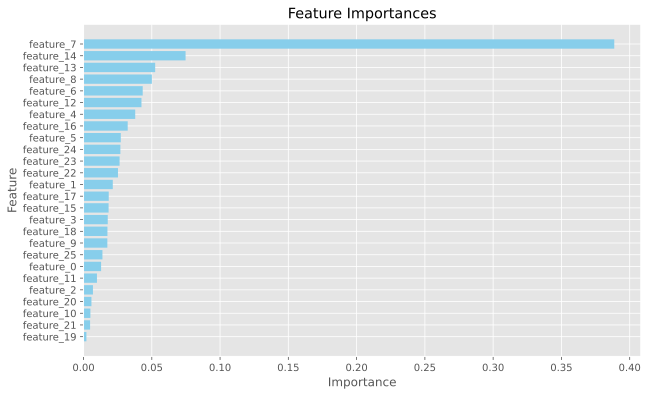

In [134]:

feature_names = [f'feature_{i}' for i in range(X.shape[1])]

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Print feature importances
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()

### XGBOOST 

In [135]:
# Define the XGBoost model
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the testing data
predictions = xgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.7580275229357798


In [136]:
# Calculate metrics
accuracy = accuracy_score(y_test, predictions)
accuracy

0.7580275229357798

In [137]:
# Calculate metrics
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
auc = roc_auc_score(y_test, probs)

In [138]:
# printing calculated metrics
print('accuracy score: ',accuracy)
print('f1 score: ',f1)
print('precision score: ',precision)
print('recall score: ',recall)
print('auc: ',auc)

accuracy score:  0.7580275229357798
f1 score:  0.8529616724738676
precision score:  0.7937743190661478
recall score:  0.9216867469879518
auc:  0.6730950243280815


## prediction on the data for submission on Zindi

In [139]:
# Make predictions on the testing data
predictions = xgb_model.predict(pred_df)

In [140]:
#To add result to original DF
reportdf['predictions'] = predictions

In [141]:
reportdf.head()

,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,dataset,age_categ,education_flag,employment_flag,bnk_acc_typ_flag,loan_freq,avg_paybacktime,clients_avg_loanAMT,clients_max_loanAMT,clients_min_loanAMT,clients_modal_loanAMT,total_loans,ontime_loans,ontime_percentage,pays_late_risk,referred_client,loan_interest2,%loan_int2,loan_rateCategories,predictions
0,8a858899538ddb8e015390510b321f08,301998974,4,40:48.0,39:35.0,10000,"12,250.00",30,not_referred,train,adult,0,1,0,3.00,28.33,"8,666.67","10,000.00","6,000.00","10,000.00",3.00,2.00,66.67,0.00,0,"2,250.00",22.50,high,1
1,8a858959537a097401537a4e316e25f7,301963615,10,43:40.0,42:34.0,40000,"44,000.00",30,not_referred,train,young_adult,0,1,1,9.00,24.11,"23,888.89","40,000.00","5,000.00","30,000.00",9.00,8.00,88.89,0.00,0,"4,000.00",10.00,low,1
2,8a8589c253ace09b0153af6ba58f1f31,301982236,6,15:11.0,15:04.0,20000,"24,500.00",30,not_referred,test,adult,0,1,1,5.00,31.20,"13,000.00","20,000.00","10,000.00","10,000.00",5.00,2.00,40.00,0.00,0,"4,500.00",22.50,high,1
3,8a858e095aae82b7015aae86ca1e030b,301971730,8,00:54.0,00:49.0,30000,"34,500.00",30,not_referred,train,adult,0,0,1,7.00,13.43,"17,142.86","30,000.00","10,000.00","10,000.00",7.00,7.00,100.00,1.00,0,"4,500.00",15.00,medium,1
4,8a858e225a28c713015a30db5c48383d,301959177,4,04:33.0,04:27.0,20000,"24,500.00",30,not_referred,test,adult,0,1,1,3.00,21.67,"10,000.00","10,000.00","10,000.00","10,000.00",3.00,3.00,100.00,1.00,0,"4,500.00",22.50,high,1


In [142]:
#Submission data 
sumissiondf=reportdf[['customerid','predictions']]
sumissiondf.to_csv('SampleSubmission.csv')


In [143]:
sumissiondf.head(5)

,customerid,predictions
0,8a858899538ddb8e015390510b321f08,1
1,8a858959537a097401537a4e316e25f7,1
2,8a8589c253ace09b0153af6ba58f1f31,1
3,8a858e095aae82b7015aae86ca1e030b,1
4,8a858e225a28c713015a30db5c48383d,1


In [144]:
#pre process the test set too